# SLIDES

https://docs.google.com/presentation/d/1Yhq7P3Dxf7Jlx3nc2fRb1BojVLjVUaMA9FJoaEg7zQo/edit?usp=sharing

# Preamble

In [ ]:
import $ivy.`org.typelevel::cats-core:2.13.0`
import $ivy.`org.typelevel::cats-free:2.13.0`

In [ ]:
import cats.*, cats.syntax.all.*
import cats.free.*

In [ ]:
extension [A](a: A)
    def |>[B](f: A => B): B = 
        f(a)

### Rose trees

In [ ]:
case class Tree[+A](root: String, children: List[Tree[?]])

object Tree: 

    def treeToString(t: Tree[?])(prefix: String, bar: String, sep: String): String = 
        prefix + sep + t.root.toString + 
        (t.children match 
            case List() => "" 
            case head :: tail => 
                "\n" + 
                (if tail.isEmpty then ""
                else tail.map(treeToString(_)(prefix + bar + "   ", "|", "├──"))
                        .mkString("\n") + "\n") +
                treeToString(head)(prefix + bar + "   ", "", "└──")       
        )

    def show[A](t: Tree[A]): String = 
        treeToString(t)("", "", "")

    given [A]: Show[Tree[A]] with 
        def show(t: Tree[A]): String = 
            treeToString(t)("", "", "")
    
    def print[A](t: Tree[A]): Unit = 
        println(show(t))

### Functor-Algebra-Coalgebra

In [ ]:
infix type Compose[F[_], G[_]] = [t] =>> F[G[t]]

given [F[_]: Functor, G[_]: Functor]: Functor[F Compose G] =
    Functor[F].compose(using Functor[G])

In [ ]:
type Algebra[F[_], A] = F[A] => A

object Algebra: 
    def apply[F[_], A](using A: Algebra[F, A]): Algebra[F, A] = A

type Coalgebra[A, F[_]] = A => F[A]

In [ ]:
/*
case class Fix[F[_]: Functor](out: F[Fix[F]]): 
    def fold[T](alg: F[T] => T): T = 
        alg(out.map(_.fold(alg)))
*/

In [ ]:
case class Fix[F[_]](out: () => F[Fix[F]])

object Fix: 
    def in[F[_]](f: => F[Fix[F]]): Fix[F] = Fix(() => f)

    // recursion schemes

    def fold[F[_]: Functor, A](alg: F[A] => A): Fix[F] => A = 
        case Fix(f) => alg(f().map(fold(alg)))

    def unfold[A](a: A)[F[_]: Functor](coalg: A => F[A]): Fix[F] =
        Fix(() => coalg(a).map(unfold(_)(coalg)))

    trait hylo[F[_]]:
        def apply[A, B](coalg: Coalgebra[A, F], alg: Algebra[F, B])(using Functor[F]): A => B = 
            (unfold(_: A)(coalg)) andThen fold(alg)

    object hylo: 
        def apply[F[_]] = new hylo[F]{}

    // map analogue for Fix and F

    def mapF[F[_]: Functor, G[_]](nat: F ~> G)(cf: Fix[F]): Fix[G] = 
        Fix(() => nat(cf.out().map(mapF(nat))))

    def mapF_atDepth[F[_]: Functor, G[_]](nat: (Int, => F[Fix[G]]) => G[Fix[G]])(muF: Fix[F]): Fix[G] = 
        def go(level: Int)(muF: => Fix[F]): Fix[G] = 
            Fix(() => nat(level, muF.out().map(go(level+1))))

        go(0)(muF)
    
    // mapFilterF: Not exactly the analogue of mapFilter for Fix and F

    def mapFilterFRec[F[_]: FunctorFilter, H[_]](nat: F ~> Compose[Option, H])(rec: Fix[F] => Option[Fix[H]])(cf: Fix[F]): Option[Fix[H]] = 
        nat(cf.out().mapFilter(rec))
            .map(Fix.in)
        
    def mapFilterF[F[_]: FunctorFilter, H[_]](nat: F ~> Compose[Option, H])(cf: Fix[F]): Option[Fix[H]] = 
        mapFilterFRec(nat)(mapFilterF(nat))(cf)
        
    def mapFilterFUntil[F[_]: FunctorFilter, H[_]](depth: Int)(nat: F ~> Compose[Option, H])(cf: Fix[F]): Option[Fix[H]] = 
        if depth == 0 then None
        else mapFilterFRec(nat)(mapFilterFUntil(depth-1)(nat))(cf)

    // sequence anologue for Fix and G Compose H

    def sequenceF_Rec[G[_]: Monad, H[_]: Traverse](rec: Fix[G Compose H] => G[Fix[H]])(ss: Fix[G Compose H]): G[Fix[H]] = 
        Monad[G].flatMap(ss.out()): 
            _.traverse(rec)
                .map(Fix.in)
    
    def sequenceF[G[_]: Monad, H[_]: Traverse](ss: Fix[G Compose H]): G[Fix[H]] = 
        sequenceF_Rec(sequenceF[G, H])(ss)
    
    def sequenceF_Until[G[_]: Monad: Alternative, H[_]: Traverse](depth: Int)(ss: Fix[G Compose H]): G[Fix[H]] = 
        if depth == 0 then Alternative[G].empty
        else sequenceF_Rec(sequenceF_Until[G, H](depth-1))(ss)

    // traverse analogue for Fix and F   
     
    def traverseF[F[_]: Functor, G[_]: Monad, H[_]: Traverse](nat: F ~> Compose[G, H])(ss: Fix[F]): G[Fix[H]] = 
        sequenceF(mapF(nat)(ss))

    // Show instance

    def truncate[F[_]: Functor](depth: Int)(mu: Fix[F]): Fix[Option Compose F] = 
        mapF_atDepth[F, Option Compose F]((level, fMuG) => if level == depth then None else Some(fMuG))(mu)

    given [F[_]: Functor](using toTree: Algebra[F, Tree[Any]]): Show[Fix[F]] with 

        val MAX = 6

        given Functor[Option Compose F] = Functor[Option].compose[F]

        given toTreeTruncated: Algebra[Option Compose F, Tree[Any]] = 
            case None => Tree("...", Nil)
            case Some(f) => toTree(f)
        def show(t: Fix[F]): String =
            fold(toTreeTruncated)(truncate(MAX)(t)).show

# Algebraic part

## Tagless-final

### NJ

In [ ]:
trait NJ[T]:
    def v(s: String): T
    def abs(s: String, t: T): T
    def app(f: T)(t1: T): T
    def prd(t1: T, t2: T): T
    def pr1(t: T): T
    def pr2(t: T): T
    def inl(t: T): T
    def inr(t: T): T
    def pat(t1: T, t2: T)(t: T): T
    
object NJ:

    type Proof = [T] => NJ[T] ?=> T 

    type ADT = /*Tuple2[?, ?] | Either[?, ?] | Function1[?, ?] |*/ Any

    type Std = Map[String, ADT] => ADT
                
    given Std_NJ: NJ[Std] with
        def v(s: String): Std = _(s) 
        def abs(s: String, t: Std): Std = 
            (env: Map[String, ADT]) => (a: Any) => t(env+(s -> a))
        def app(f: Std)(t1: Std): Std = env => f(env) match 
            case f: (a => b) =>
                t1(env) match 
                    case e: a => f(e) 
        def prd(t1: Std, t2: Std): Std = env => (t1(env), t2(env)) 
        def pr1(t: Std): Std = ??? 
        def pr2(t: Std): Std = ??? 
        def inl(t: Std): Std = env => Left(t(env))
        def inr(t: Std): Std = env => Right(t(env))
        def pat(t1: Std, t2: Std)(t: Std): Std = ??? 

    type Print = String

    given NJ[String] with 
        def v(s: String): String = s 
        def abs(s: String, t: String): String = s"λ$s.($t)" 
        def app(f: String)(t1: String): String = s"$f($t1)"
        def prd(t1: String, t2: String): String = s"($t1, $t2)"
        def pr1(t: String): String = s"$t._1"
        def pr2(t: String): String = s"$t._2"
        def inl(t: String): String = s"inl($t)"
        def inr(t: String): String = s"inr($t)" 
        def pat(t1: String, t2: String)(t: String): String = s"$pat($t1, $t2)($t)"


In [ ]:
val ex1: NJ.Proof = [T]=> NJ ?=> 
    import NJ._
    abs("f", 
        prd(
            abs("a", app(v("f"))((inl(v("a"))))), 
            abs("b", app(v("f"))((inr(v("b")))))))

In [ ]:
ex1[NJ.Print]

In [ ]:
val f = ex1[NJ.Std].apply(Map()).asInstanceOf[(Either[Int, Char] => Boolean) => (Int => Boolean, Char => Boolean)]
val (isEven, isUpper) = f{ case Left(i) => i % 2 == 0; case Right(c) => c >= 'A'}
isEven(6)
isUpper('A')

### LJ

In [ ]:
trait LJ[T]: 

    def ax(s0: String): T
    def `->l`(s0: String, t1: T, s1: String, t2: T): T
    def `->r`(s0: String, t: T): T
    def `^r`(t1: T, t2: T): T
    def `^l1`(s0: String, s1: String, t: T): T
    def `^l2`(s0: String, s1: String, t: T): T
    def `vl`(s0: String, s1: String, t1: T, s2: String, t2: T): T
    def `vr1`(t: T): T
    def `vr2`(t: T): T

object LJ: 

    type Proof = [T] => LJ[T] ?=> T

    given LJ_NJ[T](using NJ: NJ[T]): LJ[T] with 
        import NJ._

        def ax(s0: String): T = 
            v(s0) 

        def `->l`(f: String, t: T, x: String, u: T): T = 
            app(abs(x, u))(app(v(f))(t))

        def `->r`(s0: String, t: T): T =
            abs(s0, t)

        def `^r`(t1: T, t2: T): T =
            prd(t1, t2)

        def `^l1`(s0: String, s1: String, t: T): T =
            app(abs(s1, t))(pr1(v(s0)))
    
        def `^l2`(s0: String, s1: String, t: T): T =
            app(abs(s1, t))(pr2(v(s0)))
    
        def `vl`(s0: String, s1: String, t1: T, s2: String, t2: T): T =
            pat(abs(s1, t1), abs(s2, t2))(v(s0))
    
        def `vr1`(t: T): T =
            inl(t)
    
        def `vr2`(t: T): T = 
            inr(t)

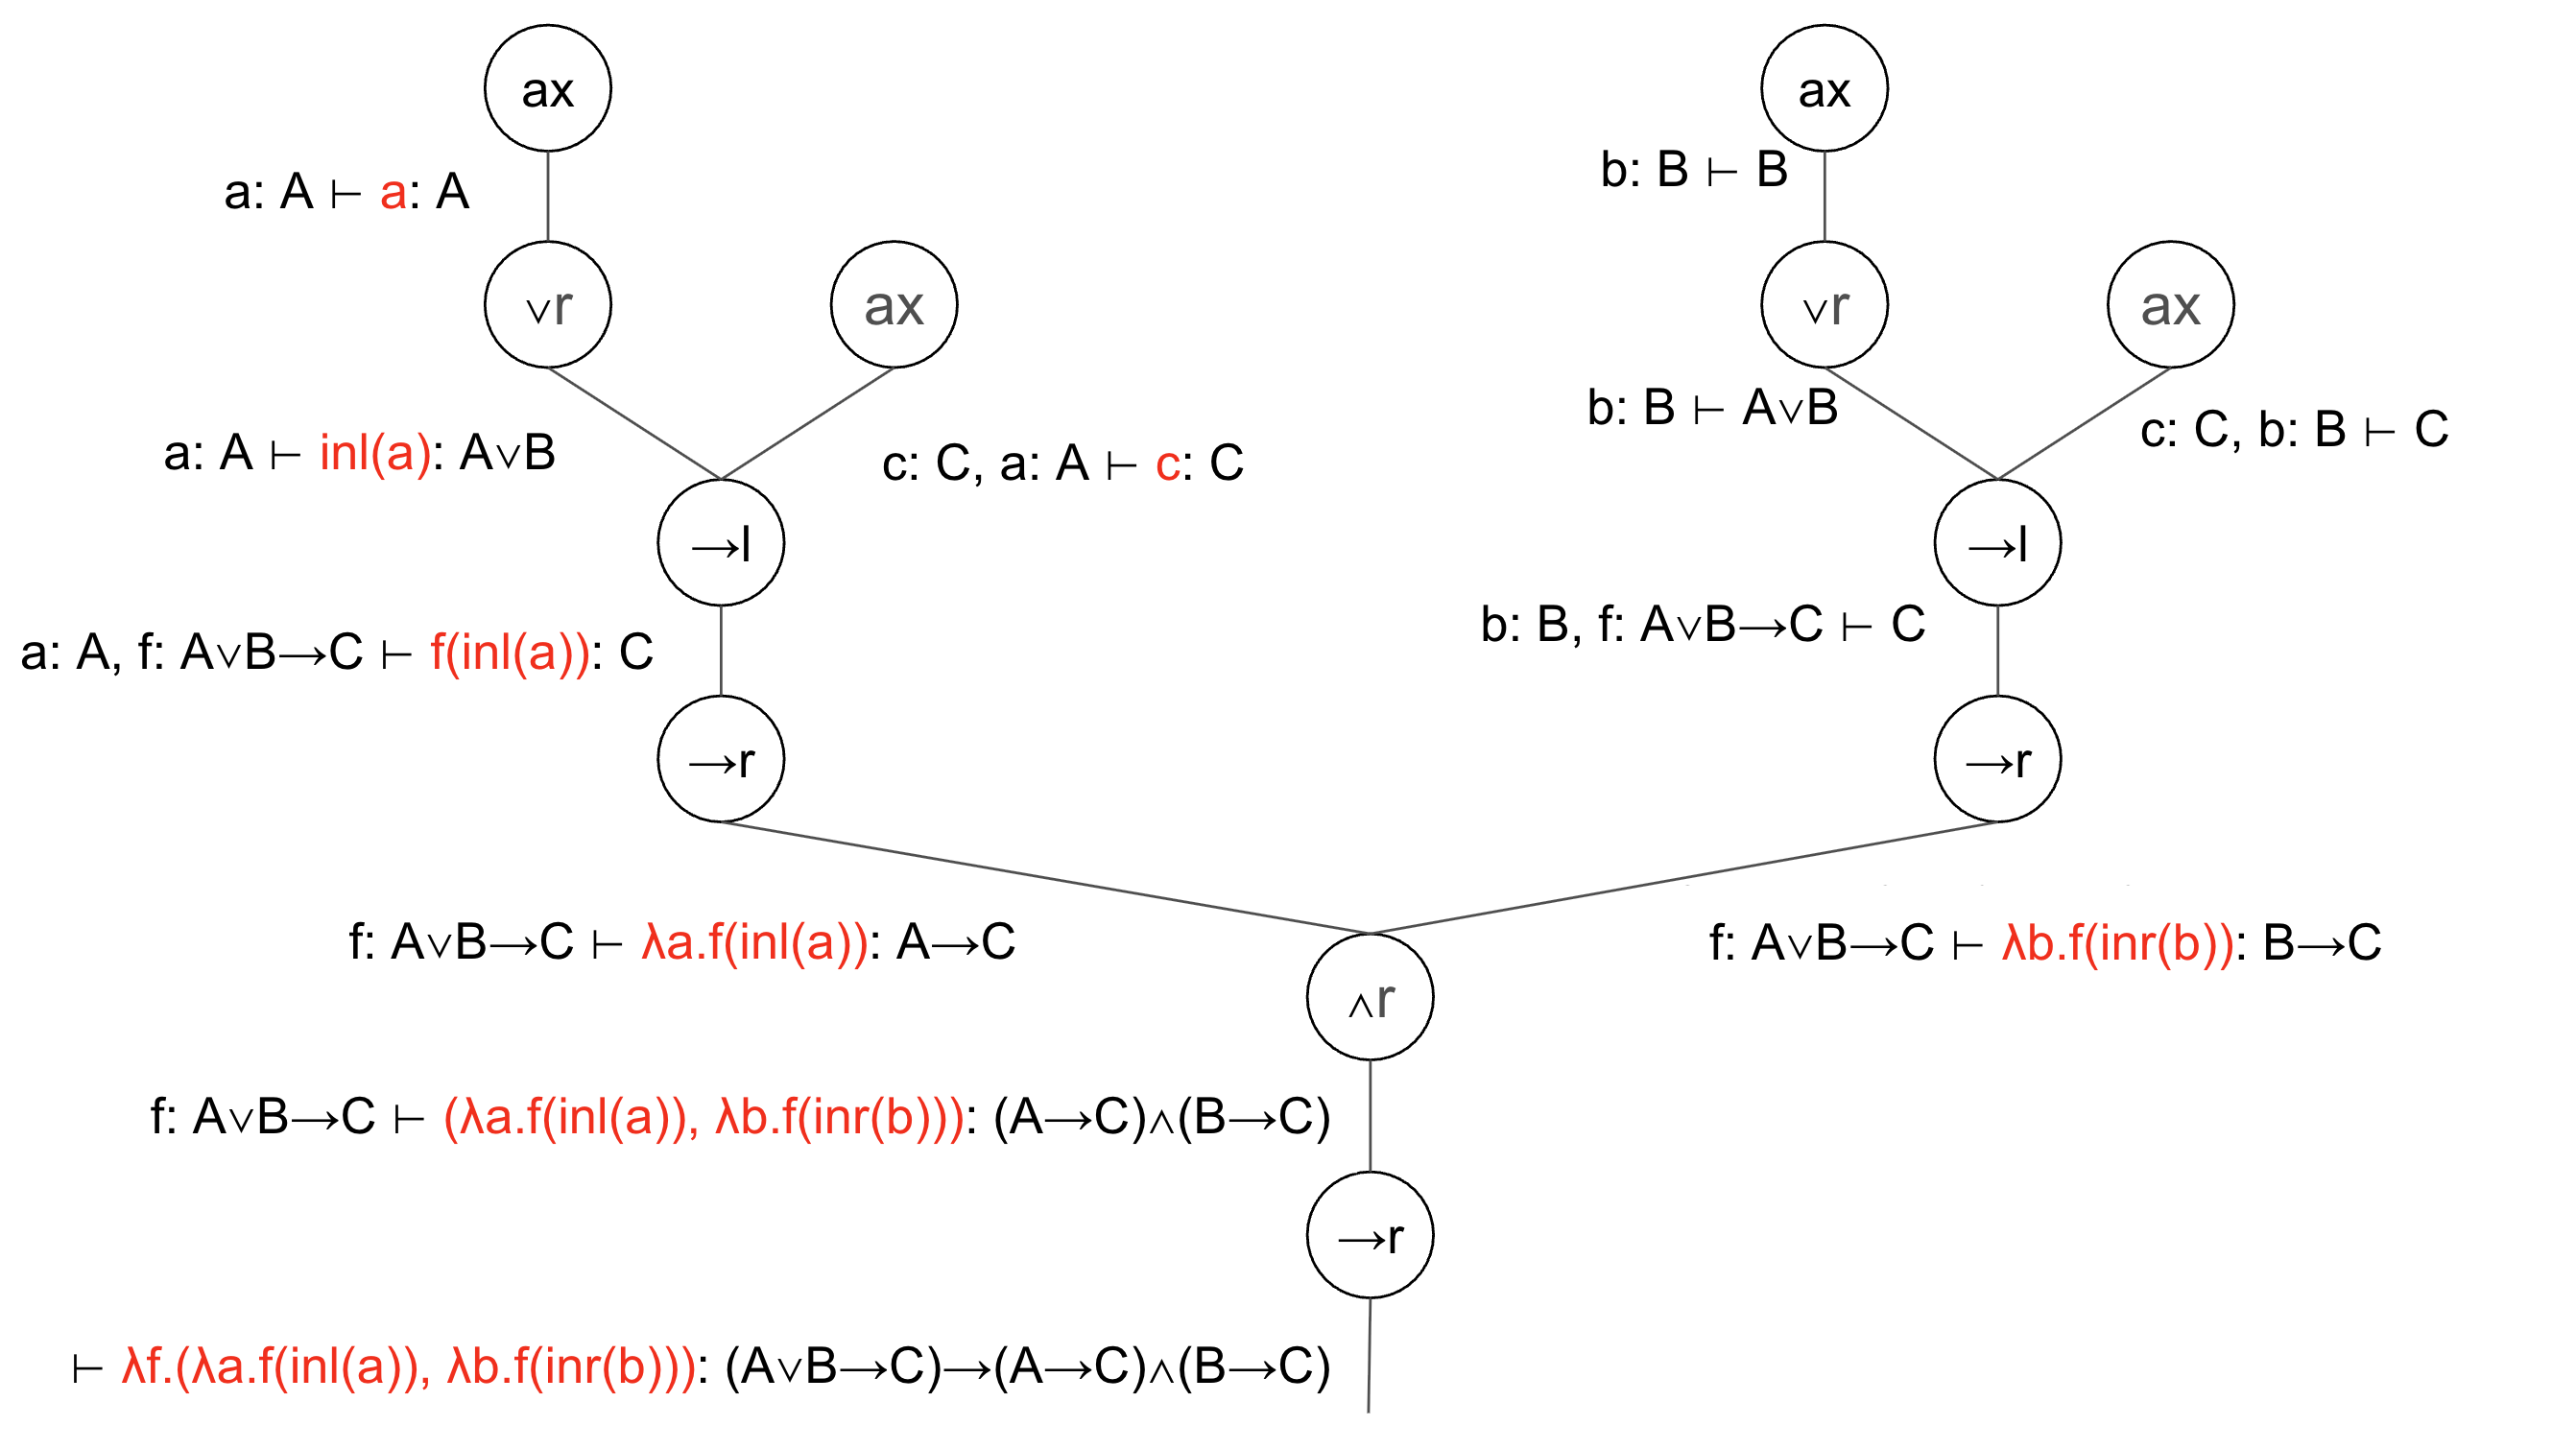

In [ ]:
val proof: LJ.Proof = [T] => LJ ?=> 
    import LJ.* 

    `->r`("f", 
          `^r`(
              `->r`("a", 
                    `->l`("f", 
                          `vr1`(ax("a")), 
                          "c",
                          ax("c"))), 
              `->r`("b", 
                    `->l`("f", 
                          `vr2`(ax("b")), 
                          "c",
                          ax("c")))
              ))

In [ ]:
proof[NJ.Print]

In [ ]:
val foo = proof[NJ.Std](Map()).asInstanceOf[(Either[Int, Char] => Boolean) => (Int => Boolean, Char => Boolean)]
val (isEven, isUpper) = foo{ case Left(i) => i % 2 == 0; case Right(c) => c >= 'A' && c <= 'Z'}
isEven(0)
isUpper('a')

## F-algebra

### LJ

#### Functor

In [ ]:
enum LJ_F[T]:

    case ax[T](s0: String) extends LJ_F[T]
    case `->l`[T](s0: String, t1: T, s1: String, t2: T) extends LJ_F[T]
    case `->r`[T](s0: String, t: T) extends LJ_F[T]
    case `^r`[T](t1: T, t2: T) extends LJ_F[T]
    case `^l1`[T](s0: String, s1: String, t: T) extends LJ_F[T]
    case `^l2`[T](s0: String, s1: String, t: T) extends LJ_F[T]
    case `vl`[T](s0: String, s1: String, t1: T, s2: String, t2: T) extends LJ_F[T]
    case `vr1`[T](t: T) extends LJ_F[T]
    case `vr2`[T](t: T) extends LJ_F[T]

object LJ_F: 

    given Traverse[LJ_F] with 
        def traverse[G[_]: Applicative, A, B](fa: LJ_F[A])(f: A => G[B]): G[LJ_F[B]] = fa match
            case ax(s0) => ax(s0).pure
            case `->l`(s0, t1, s1, t2) => (f(t1), f(t2)).mapN(`->l`(s0, _, s1, _))
            case `->r`(s0, t) => f(t).map(`->r`(s0, _))
            case `^r`(t1, t2) => (f(t1), f(t2)).mapN(`^r`.apply)
            case `^l1`(s0, s1, t) => f(t).map(`^l1`(s0, s1, _))
            case `^l2`(s0, s1, t) => f(t).map(`^l2`(s0, s1, _))
            case `vl`(s0, s1, t1, s2, t2) => (f(t1), f(t2)).mapN(`vl`(s0, s1, _, s2, _))
            case `vr1`(t) => f(t).map(`vr1`.apply)
            case `vr2`(t) => f(t).map(`vr2`.apply)

        def foldLeft[A, B](fa: LJ_F[A], b: B)(f: (B, A) => B): B = ??? 

        def foldRight[A, B](fa: LJ_F[A], lb: Eval[B])(f: (A, Eval[B]) => Eval[B]): Eval[B] = ??? 

    given toTree: (LJ_F[Tree[Any]] => Tree[Any]) = 
        case ax(s0) => Tree(s"ax($s0)", Nil)
        case `->l`(s0, t1, s1, t2) => Tree(s"->l($s0, $s1)", List(t1, t2)) 
        case `->r`(s0, t) => Tree(s"->r($s0)", List(t))
        case `^r`(t1, t2) => Tree(s"^r", List(t1, t2))
        case `^l1`(s0, s1, t) => Tree(s"^l1($s0, $s1)", List(t))
        case `^l2`(s0, s1, t) => Tree(s"^l2($s0, $s1)", List(t))
        case `vl`(s0, s1, t1, s2, t2) => Tree(s"vl($s0, $s1, $s2)", List(t1, t2)) 
        case `vr1`(t) => Tree("vr1", List(t))
        case `vr2`(t) => Tree("vr2", List(t))

#### Algebra

In [ ]:
type LJ[T] = LJ_F[T] => T

object LJ: 

    // type Proof[T] = [T] => LJ[T] ?=> T

    type Proof = Fix[LJ_F]

    given toNJ[T](using NJ: NJ[T]): LJ[T] =
        import NJ.*
        import LJ_F.*

        {
            case ax(s0) => v(s0)
            case `->l`(s0, t1, s1, t2) => app(abs(s1, t2))(app(v(s0))(t1))
            case `->r`(s0, t) => abs(s0, t)
            case `^r`(t1, t2) => prd(t1, t2)
            case `^l1`(s0, s1, t) => app(abs(s1, t))(pr1(v(s0)))
            case `^l2`(s0, s1, t) => app(abs(s1, t))(pr2(v(s0)))
            case `vl`(s0, s1, t1, s2, t2) => pat(abs(s1, t1), abs(s2, t2))(v(s0))
            case `vr1`(t) => inl(t)
            case `vr2`(t) => inr(t)
        }

In [ ]:
val proof: LJ.Proof =
    import LJ_F.*

    Fix.in(`->r`("f", 
        Fix.in(`^r`(
            Fix.in(`->r`("a", 
                    Fix.in(`->l`("f", 
                          Fix.in(`vr1`(Fix.in(ax("a")))), 
                          "c",
                          Fix.in(ax("c")))))), 
            Fix.in(`->r`("b", 
                    Fix.in(`->l`("f", 
                          Fix.in(`vr2`(Fix.in(ax("b")))), 
                          "c",
                          Fix.in(ax("c"))))))
        ))))

In [ ]:
Fix.fold(LJ.toNJ[NJ.Print])(proof)

# Coalgebraic part

## Sequents

In [ ]:
import scala.reflect.{ClassTag, classTag}

In [ ]:
enum Type[T]: 
    case atom[T](s: String) extends Type[T]
    case implies[T1, T2](t1: Type[T1], t2: Type[T2]) extends Type[T1 => T2]
    case and[T1, T2](t1: Type[T1], t2: Type[T2]) extends Type[(T1, T2)]
    case or[T1, T2](t1: Type[T1], t2: Type[T2]) extends Type[T1 Either T2]

object Type:

    def apply[T](using T: Type[T]): Type[T] = T

    given Type_Atom[T: ClassTag]: Type[T] = 
        val name = classTag[T].runtimeClass.getName()
        atom[T]((""".*\$(.*)""".r).findFirstMatchIn(name).fold(name)(_.group(1)))

    given Type_Implies[T1, T2](using t1: Type[T1], t2: Type[T2]): Type[T1 => T2] = Type.implies(t1, t2)
    
    given Type_And[T1, T2](using t1: Type[T1], t2: Type[T2]): Type[(T1, T2)] = Type.and(t1, t2)
    
    given Type_Or[T1, T2](using t1: Type[T1], t2: Type[T2]): Type[T1 Either T2] = Type.or(t1, t2)

    def show(t: Type[?]): String = 
        t match 
            case atom(s) => s
            case implies(t1, t2) => "(" + show(t1) + " => " + show(t2) + ")"
            case and(t1, t2) => "(" + show(t1) + " ^ " + show(t2) + ")"
            case or(t1, t2) => "(" + show(t1) + " v " + show(t2) + ")"

In [ ]:
type Env[T <: Tuple] <: Tuple = T match 
    case EmptyTuple => EmptyTuple
    case (s, h) *: t => (s, Type[h]) *: Env[t]

object Env: 
    def apply[T <: Tuple](using E: Env[T]): Env[T] = E

    given Env[EmptyTuple] = 
        EmptyTuple

    given [k <: String, H: Type, T <: Tuple: Env](using V: ValueOf[k]): Env[(k, H) *: T] = 
        (V.value, Type[H]) *: summon[Env[T]]

    class Contains(i: Int): 
        def unapply[T <: Tuple](env: Env[T]): Option[(String, Type[?])] = 
            if i < env.size then Some(env(i).asInstanceOf[(String, Type[?])])
            else None

    def show(env: Tuple): String = 
        (env: @unchecked) match 
            case EmptyTuple => ""
            case (k: String, h: Type[?]) *: EmptyTuple => k + ": " + Type.show(h)
            case (k: String, h: Type[?]) *: tail  => k + ": " + Type.show(h) + ", " + show(tail)

In [ ]:
val elem1 = Env.Contains(1)

In [ ]:
type TypeOf[k <: String, T <: Tuple] = T match 
    case (`k`, t) *: tail => t
    case _ *: tail => TypeOf[k, tail]

In [ ]:
extension [E <: Tuple](env: Env[E])
    def prepend[B](s: String, t: Type[B]): Env[(s.type, B) *: E] = // (s.type, Type[B]) *: Env[E] = 
        (s, t) *: env

In [ ]:
import Env.given

In [ ]:
case class ⊢[E <: Tuple, A](env: Env[E], con: Type[A]):
    def nextVar: String = 
        s"v${env.size}"

object `⊢` : 
    def apply[E <: Tuple, A](using S: ⊢[E, A]): ⊢[E, A] = S 

    given [E <: Tuple: Env, A: Type]: ⊢[E, A] = 
        ⊢(Env[E], Type[A])

    def show(s: ⊢[?, ?]): String = 
        Env.show(s.env) + " ⊢ " + Type.show(s.con)

In [ ]:
type Sequent[E <: Tuple, A] = ⊢[E, A]

In [ ]:
val seq1 = ⊢[EmptyTuple, (Either[Int, Char] => String) => (Int => String, Char => String)]

In [ ]:
⊢.show(⊢[("f", Int) *: ("g", Int) *: EmptyTuple, Int])

In [ ]:
def seq2[A: Type, B: Type, C: Type]
    : EmptyTuple ⊢ ((Either[A, B] => C) => (A => C, B => C)) =
    summon

## SearchSpace

In [ ]:
type LJ_Coalg[T] = T => LJ_F[T]

In [ ]:
Functor[LazyList Compose LJ_F]

In [ ]:
import scala.language.implicitConversions

In [ ]:
given Conversion[PartialFunction[? ⊢ ?, LJ_F[? ⊢ ?]], (? ⊢ ?) => LazyList[LJ_F[? ⊢ ?]]] = 
    pf => a => LazyList.from(pf.lift(a))

In [ ]:
extension (f: (? ⊢ ?) => LazyList[LJ_F[? ⊢ ?]])
    infix def ++(g: (? ⊢ ?) => LazyList[LJ_F[? ⊢ ?]]): (? ⊢ ?) => LazyList[LJ_F[? ⊢ ?]] = 
        a => f(a) ++ g(a)

In [ ]:
given toL[B]: Conversion[Int => PartialFunction[? ⊢ ?, LJ_F[? ⊢ ?]], (? ⊢ ?) => LazyList[LJ_F[? ⊢ ?]]] = 
    pfi => seq => 
        (0 to seq.env.size-1) 
            .map(pfi) 
            .map(pf => LazyList.from(pf.lift(seq)))
            .foldLeft(LazyList())(_ ++ _)

In [ ]:
type SearchSpace = Fix[LazyList Compose LJ_F]

object SearchSpace: 

    def apply[Γ <: Tuple: Env, A: Type](s: Γ⊢A): Fix[LazyList Compose LJ_F] = 
        Fix.unfold(s)(Coalg)

    given toTree: ((LazyList Compose LJ_F)[Tree[Any]] => Tree[Any]) = 
        nel => Tree("()", nel.toList.map(LJ_F.toTree))

    given Coalg: ((? ⊢ ?) => LazyList[LJ_F[? ⊢ ?]]) =
        ax_coalg ++
        `->l_coalg` ++
        `->r_coalg` ++
        /* ... */
        `^r_coalg` ++ 
        `^l1_coalg` ++
        `^l2_coalg` ++ 
        `vr1_coalg` ++
        `vr2_coalg` ++ 
        `vl_coalg`

    import LJ_F.*
    import Type.*

    val ax_coalg: Int => PartialFunction[? ⊢ ?, ax[? ⊢ ?]] = i =>
        val Ci = Env.Contains(i)
        {
            case ⊢(gamma@Ci(v, a), c) if a == c =>
                ax(v)
        }

    val `->l_coalg`: Int => PartialFunction[? ⊢ ?, `->l`[? ⊢ ?]] = i =>
        val Ci = Env.Contains(i)
        {
            case seq@ ⊢(gamma@Ci(f, implies(a, b)), c) =>
                val x = seq.nextVar
                `->l`(f, ⊢(gamma, a), x, ⊢(gamma.prepend(x, b), c))
        }

    val `->r_coalg`: PartialFunction[? ⊢ ?, `->r`[? ⊢ ?]] = 
        case seq@ ⊢(gamma, implies(a, b)) =>
            val x = seq.nextVar
            `->r`(x, ⊢(gamma.prepend(x, a), b))

    val `^r_coalg`: PartialFunction[? ⊢ ?, `^r`[? ⊢ ?]] = 
        case seq@ ⊢(gamma, and(a, b)) =>
            `^r`(⊢(gamma, a), ⊢(gamma, b)) 

    val `^l1_coalg`: Int => PartialFunction[? ⊢ ?, `^l1`[? ⊢ ?]] = i => 
        val Ci = Env.Contains(i)
        {
            case seq@ ⊢(gamma@Ci(f, and(a, b)), c) =>
                val x = seq.nextVar
                `^l1`(f, x, ⊢(gamma.prepend(x, a), c))
        }

    val `^l2_coalg`: Int => PartialFunction[? ⊢ ?, `^l2`[? ⊢ ?]] = i => 
        val Ci = Env.Contains(i)
        {
            case seq@ ⊢(gamma@Ci(f, and(a, b)), c) =>
                val x = seq.nextVar
                `^l2`(f, x, ⊢(gamma.prepend(x, b), c))
        }

    val `vl_coalg`: Int => PartialFunction[? ⊢ ?, `vl`[? ⊢ ?]] = i => 
        val Ci = Env.Contains(i)
        {
            case seq@ ⊢(gamma@Ci(f, or(a, b)), c) =>
                val x = seq.nextVar
                `vl`(f, x, ⊢(gamma.prepend(x, a), c), x, ⊢(gamma.prepend(x, b), c))
        }

    val `vr1_coalg`: PartialFunction[? ⊢ ?, `vr1`[? ⊢ ?]] = 
        case ⊢(gamma, or(a, b)) =>
            `vr1`(⊢(gamma, a)) 

    val `vr2_coalg`: PartialFunction[? ⊢ ?, `vr2`[? ⊢ ?]] = 
        case ⊢(gamma, or(a, b)) =>
            `vr2`(⊢(gamma, b)) 

In [ ]:
SearchSpace.Coalg(seq1)

In [ ]:
val ss: SearchSpace = SearchSpace(seq1)

## Search Strategy

In [ ]:
type SearchStrategy = 
    Fix[LazyList Compose LJ_F] => 
    LazyList[Fix[LJ_F]]

object SearchStrategy: 

    val DF: SearchStrategy =
        Fix.sequenceF

    val ID: SearchStrategy = 
        val MAX = 10

        def go(depth: Int)(ss: SearchSpace): LazyList[Fix[LJ_F]] =
            val results = Fix.sequenceF_Until(depth)(ss)
            if results != Nil then results
            else if depth > MAX then LazyList.empty
            else go(depth+1)(ss)
        
        go(1)



In [ ]:
val proofs: List[Fix[LJ_F]] = SearchStrategy.ID(SearchSpace(seq1)).take(5).toList

In [ ]:
⊢[EmptyTuple, Int]

In [ ]:
def proofs[F: Type]: [T] => NJ[T] ?=> LazyList[T] = [T] => NJ ?=> 
    Fix.unfold(⊢[EmptyTuple, F])[LazyList Compose LJ_F](SearchSpace.Coalg)
        .|>(SearchStrategy.ID)
        .map(Fix.fold(LJ.toNJ[T]))



In [ ]:
proofs[Int => String => Int][NJ.Print]

In [ ]:
trait p; trait q; trait r

In [ ]:
proofs[p => q => p][NJ.Print]
proofs[(p => q => r) => (p => q) => p => r][NJ.Print]